# Task 2: Sentiment & Thematic Analysis for Fintech Reviews

In this notebook, we analyze customer reviews from Ethiopian banking apps:

- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank

### Objectives:
- Perform sentiment analysis (Positive, Neutral, Negative)
- Identify common complaints
- Extract feature requests
- Compare banks based on customer experience

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

## Load Cleaned Dataset
We load the dataset created in Task 1 after scraping and preprocessing.

In [2]:
df = pd.read_csv("../data/raw/fintech_reviews_clean.csv")

df.head()

,review,rating,date,bank,source
0,so nice,5,2026-05-19,CBE,Google Play
1,nice,5,2026-05-19,CBE,Google Play
2,cde,2,2026-05-19,CBE,Google Play
3,"fast, easy, and save time.",5,2026-05-19,CBE,Google Play
4,jamal Abarhim,5,2026-05-19,CBE,Google Play


## Sentiment Analysis using VADER

We classify reviews into:
- Positive
- Neutral
- Negative

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [4]:
df["sentiment"] = df["review"].apply(get_sentiment)

df.head()

,review,rating,date,bank,source,sentiment
0,so nice,5,2026-05-19,CBE,Google Play,positive
1,nice,5,2026-05-19,CBE,Google Play,positive
2,cde,2,2026-05-19,CBE,Google Play,neutral
3,"fast, easy, and save time.",5,2026-05-19,CBE,Google Play,positive
4,jamal Abarhim,5,2026-05-19,CBE,Google Play,neutral


## Sentiment Distribution by Bank

We visualize how customers feel about each bank.

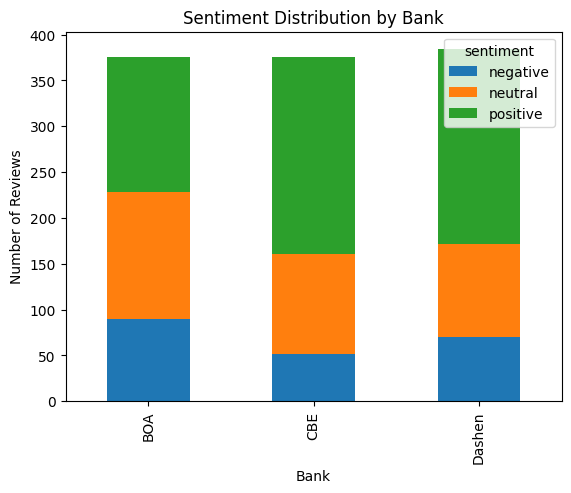

In [5]:
sentiment_counts = df.groupby(["bank", "sentiment"]).size().unstack()

sentiment_counts.plot(kind="bar", stacked=True)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()

## Extracting Negative Reviews

We focus on negative feedback to identify system issues and complaints.

In [6]:
negative_reviews = df[df["sentiment"] == "negative"]

negative_reviews.head()

,review,rating,date,bank,source,sentiment
10,"bad at processing, wht do u mean by I can't ma...",1,2026-05-18,CBE,Google Play,negative
14,I have an account of cbe when i open the accou...,1,2026-05-18,CBE,Google Play,negative
26,Please make the CBE Noor toggle to be optional...,2,2026-05-17,CBE,Google Play,negative
28,It stopped working on its own. When you check ...,1,2026-05-17,CBE,Google Play,negative
29,The most backward and unstable financial app i...,1,2026-05-16,CBE,Google Play,negative


## Feature & Complaint Extraction (TF-IDF)

We extract common complaint keywords from negative reviews.


In [7]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=20)

X = vectorizer.fit_transform(negative_reviews["review"].astype(str))

keywords = vectorizer.get_feature_names_out()

print("Top Complaint Keywords:")
print(keywords)

Top Complaint Keywords:
['account' 'app' 'bad' 'bank' 'banking' 'doesn' 'fix' 'mobile' 'money'
 'open' 'problem' 'says' 'slow' 'time' 'transfer' 'update' 'use' 'work'
 'working' 'worst']


## Feature Tagging

We identify key product issues such as:
- login problems
- OTP issues
- slow transfers
- app crashes

In [8]:
features = ["login", "fingerprint", "transfer", "otp", "slow", "crash"]

def extract_features(text):
    text = str(text).lower()
    return [f for f in features if f in text]

df["feature_tags"] = df["review"].apply(extract_features)

df[["review", "feature_tags"]].head()

,review,feature_tags
0,so nice,[]
1,nice,[]
2,cde,[]
3,"fast, easy, and save time.",[]
4,jamal Abarhim,[]


## Most Common Customer Issues

We count how often each feature is mentioned in complaints.

In [9]:
all_features = sum(df["feature_tags"], [])

feature_counts = Counter(all_features)

feature_counts

Counter({'transfer': 42,
         'slow': 29,
         'crash': 19,
         'login': 8,
         'otp': 6,
         'fingerprint': 1})

## Bank-Level Sentiment Comparison

We compare customer satisfaction across banks.

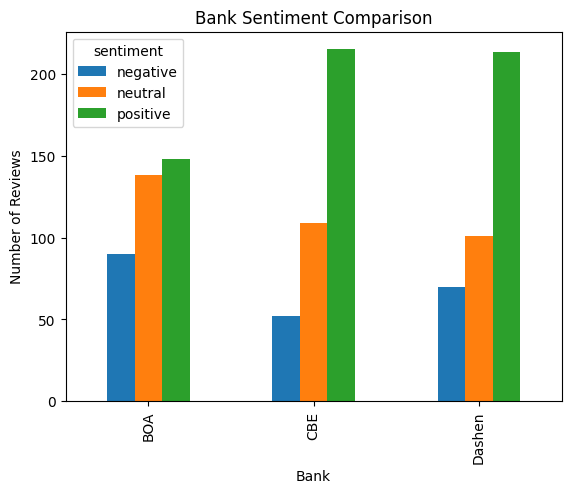

In [10]:
df.groupby(["bank", "sentiment"]).size().unstack().plot(kind="bar")

plt.title("Bank Sentiment Comparison")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()